In [1]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:

# Load libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn import datasets
# Import train_test_split function
from sklearn.model_selection import train_test_split
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Import Support Vector Classifier
from sklearn.svm import SVC

# Load data
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) # 70% training and 30% test


# Create adaboost classifer object
abc = AdaBoostClassifier(n_estimators=50,
                         learning_rate=1, random_state=1234)

abc_svm = AdaBoostClassifier(n_estimators=50, estimator = SVC(probability=True),
                         learning_rate=1, random_state=1234)
# Train Adaboost Classifer
model = abc.fit(X_train, y_train)

model2 = abc_svm.fit(X_train, y_train)


#Predict the response for test dataset
y_pred = model.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy Ada_Tree:",metrics.accuracy_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)



#Predict the response for test dataset
y_pred = model2.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy Ada_SVM:",metrics.accuracy_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)



Accuracy Ada_Tree: 0.9333333333333333
[[11  0  0]
 [ 0 16  1]
 [ 0  2 15]]
Accuracy Ada_SVM: 0.9777777777777777
[[11  0  0]
 [ 0 16  1]
 [ 0  0 17]]


INFLUENCIA DEL NUMERO DE CLASIFICADORES....


Evaluando el impacto del numero de clasificadores:
Clasificadores: 1, Accuracy Ada (Test): 0.6222222222222222, Accuracy Ada (Train): 0.6857142857142857
Clasificadores: 5, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714
Clasificadores: 10, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714
Clasificadores: 15, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714
Clasificadores: 20, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714
Clasificadores: 25, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714
Clasificadores: 30, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714
Clasificadores: 50, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714
Clasificadores: 100, Accuracy Ada (Test): 0.9333333333333333, Accuracy Ada (Train): 0.9714285714285714


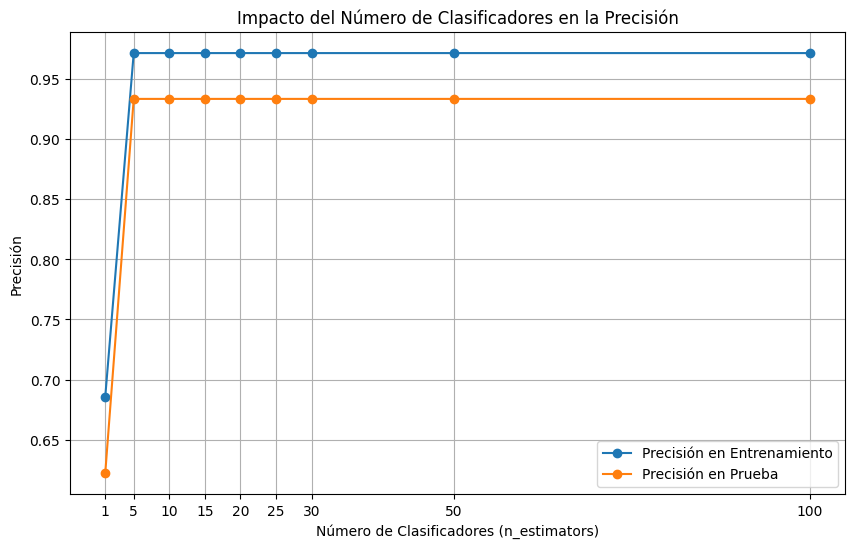

In [ ]:
# Define a range of learning rates to test

K = [1, 5, 10, 15, 20, 25, 30, 50, 100]
lr=5

print("Evaluando el impacto del numero de clasificadores:")
Acu_train =[]
Acu_test =[]
for n in K:
  # Create AdaBoostClassifier object with current learning rate
  abc = AdaBoostClassifier(n_estimators=n, learning_rate=lr, estimator = SVC(probability=True), random_state=1234)

  # Train AdaBoost Classifier
  # Aquí entrenas el modelo 'abc' con el learning_rate actual
  model = abc.fit(X_train, y_train)

  # Predict the response for test dataset
  y_pred_test = model.predict(X_test)

  # Predict the response for train dataset
  y_pred_train = model.predict(X_train)

  # Model Accuracy for test set
  accuracy_test = metrics.accuracy_score(y_test, y_pred_test)

  # Model Accuracy for train set
  accuracy_train = metrics.accuracy_score(y_train, y_pred_train)
  Acu_train.append(accuracy_train)
  Acu_test.append(accuracy_test)

  print(f"Clasificadores: {n}, Accuracy Ada (Test): {accuracy_test}, Accuracy Ada (Train): {accuracy_train}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) # Ajusta el tamaño del gráfico si es necesario
plt.plot(K, Acu_train, marker='o', linestyle='-', label='Precisión en Entrenamiento')
plt.plot(K, Acu_test, marker='o', linestyle='-', label='Precisión en Prueba')

plt.title('Impacto del Número de Clasificadores en la Precisión')
plt.xlabel('Número de Clasificadores (n_estimators)')
plt.ylabel('Precisión')
plt.xticks(K) # Muestra las etiquetas de los clasificadores en el eje x
plt.grid(True)
plt.legend() # Muestra la leyenda
plt.show()

Evaluando el impacto del numero de clasificadores y learning rate:

Evaluando con Learning Rate: 0.1
  Clasificadores: 1, Accuracy Ada (Test): 0.6000, Accuracy Ada (Train): 0.6667
  Clasificadores: 5, Accuracy Ada (Test): 0.2444, Accuracy Ada (Train): 0.3714
  Clasificadores: 10, Accuracy Ada (Test): 0.2444, Accuracy Ada (Train): 0.3714
  Clasificadores: 15, Accuracy Ada (Test): 0.8667, Accuracy Ada (Train): 0.9333
  Clasificadores: 20, Accuracy Ada (Test): 0.9111, Accuracy Ada (Train): 0.9333
  Clasificadores: 25, Accuracy Ada (Test): 0.9556, Accuracy Ada (Train): 0.9619
  Clasificadores: 30, Accuracy Ada (Test): 0.9556, Accuracy Ada (Train): 0.9714
  Clasificadores: 50, Accuracy Ada (Test): 0.9778, Accuracy Ada (Train): 0.9714
  Clasificadores: 100, Accuracy Ada (Test): 0.9778, Accuracy Ada (Train): 0.9714

Evaluando con Learning Rate: 0.5
  Clasificadores: 1, Accuracy Ada (Test): 0.6000, Accuracy Ada (Train): 0.6667
  Clasificadores: 5, Accuracy Ada (Test): 0.8222, Accuracy Ada (Tra

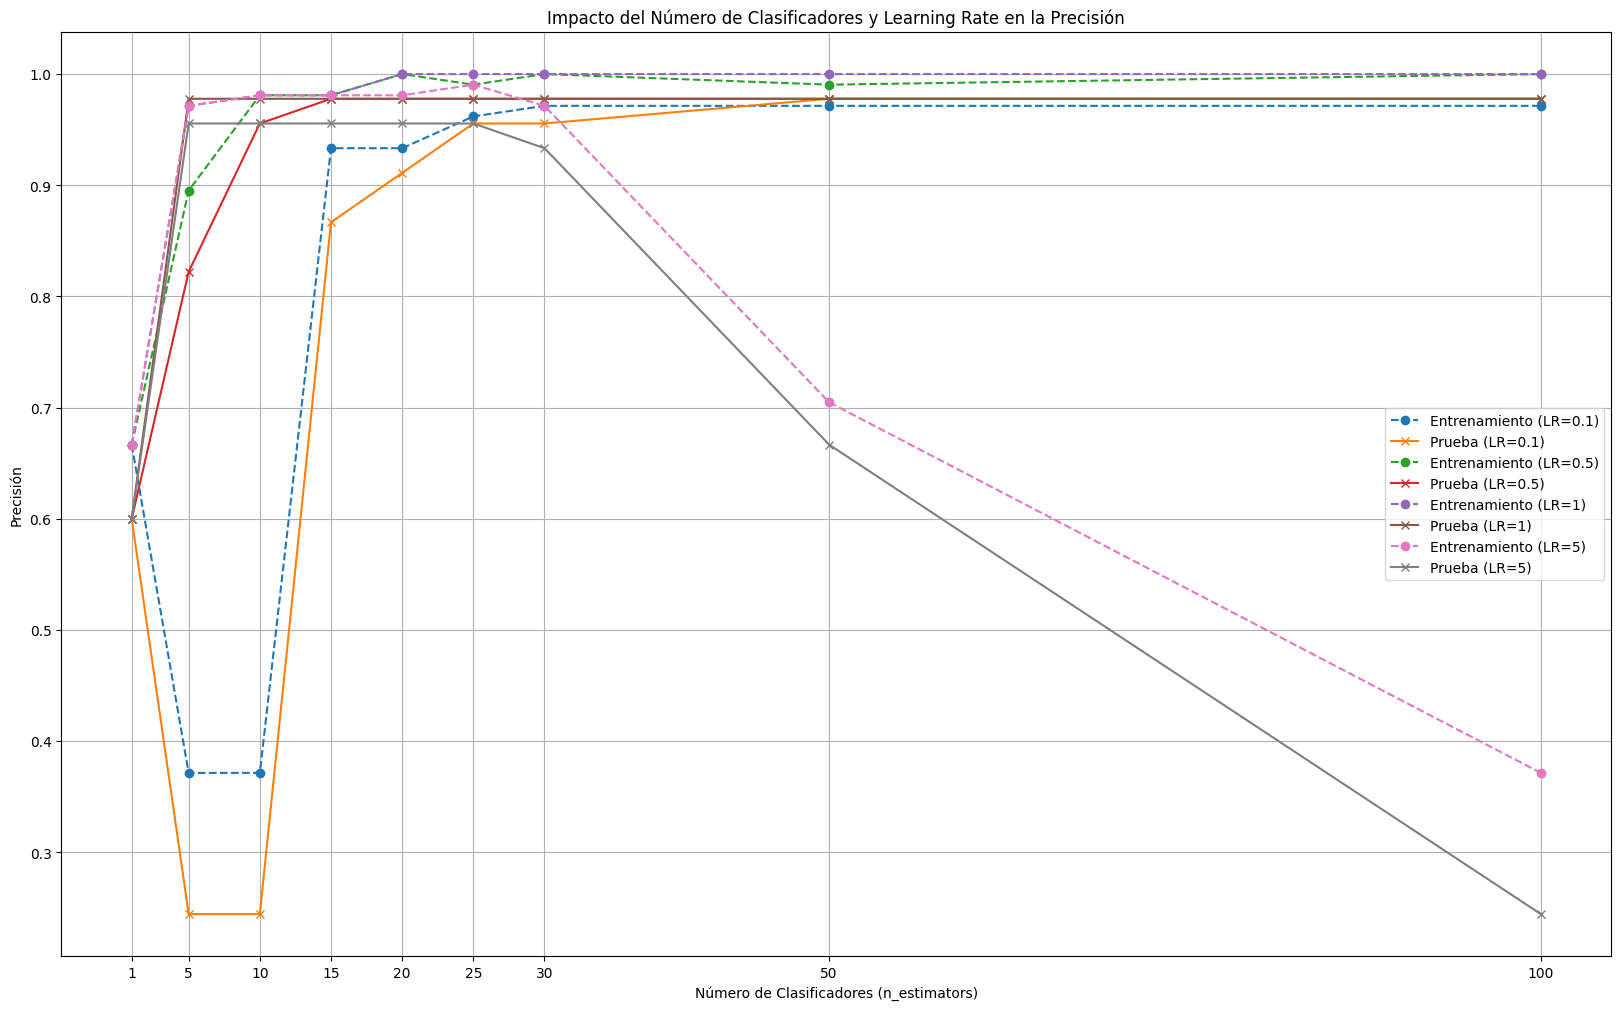

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Importar numpy para trabajar con arrays si es necesario

# Define a range of learning rates to test
learning_rates = [0.1, 0.5, 1, 5] # Define los learning rates que quieres graficar
K = [1, 5, 10, 15, 20, 25, 30, 50, 100]

# Diccionarios para almacenar las precisiones para cada learning rate
accuracy_train_by_lr = {}
accuracy_test_by_lr = {}

print("Evaluando el impacto del numero de clasificadores y learning rate:")

for lr in learning_rates:
  print(f"\nEvaluando con Learning Rate: {lr}")
  Acu_train = []
  Acu_test = []
  for n in K:
    # Create AdaBoostClassifier object with current learning rate and n_estimators
    abc = AdaBoostClassifier(n_estimators=n, learning_rate=lr, estimator=SVC(probability=True), random_state=1234)

    # Train AdaBoost Classifier
    model = abc.fit(X_train, y_train)

    # Predict the response for test dataset
    y_pred_test = model.predict(X_test)

    # Predict the response for train dataset
    y_pred_train = model.predict(X_train)

    # Model Accuracy for test set
    accuracy_test = metrics.accuracy_score(y_test, y_pred_test)

    # Model Accuracy for train set
    accuracy_train = metrics.accuracy_score(y_train, y_pred_train)

    Acu_train.append(accuracy_train)
    Acu_test.append(accuracy_test)

    print(f"  Clasificadores: {n}, Accuracy Ada (Test): {accuracy_test:.4f}, Accuracy Ada (Train): {accuracy_train:.4f}")

  # Almacenar las precisiones para este learning rate
  accuracy_train_by_lr[lr] = Acu_train
  accuracy_test_by_lr[lr] = Acu_test



plt.figure(figsize=(20, 12)) # Ajusta el tamaño del gráfico si es necesario

for lr in learning_rates:
  plt.plot(K, accuracy_train_by_lr[lr], marker='o', linestyle='--', label=f'Entrenamiento (LR={lr})')
  plt.plot(K, accuracy_test_by_lr[lr], marker='x', linestyle='-', label=f'Prueba (LR={lr})')

plt.title('Impacto del Número de Clasificadores y Learning Rate en la Precisión')
plt.xlabel('Número de Clasificadores (n_estimators)')
plt.ylabel('Precisión')
plt.xticks(K) # Muestra las etiquetas de los clasificadores en el eje x
plt.grid(True)
plt.legend() # Muestra la leyenda
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
lr=0.1
abc = AdaBoostClassifier(n_estimators=15, learning_rate=lr, estimator = SVC(probability=True), random_state=1234)

# Define the cross-validation strategy
# Usamos StratifiedKFold para mantener la proporción de clases en cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234) # Puedes ajustar n_splits

# Perform cross-validation
# cross_val_score devuelve la puntuación para cada fold
scores = cross_val_score(abc, X, y, cv=cv, scoring='accuracy')

# Calculate the mean and standard deviation of the scores
mean_accuracy = scores.mean()
std_accuracy = scores.std()

print(f"Learning Rate: {lr}, Mean Accuracy (CV): {mean_accuracy:.4f}, Std Dev (CV): {std_accuracy:.4f}")

Learning Rate: 0.1, Mean Accuracy (CV): 0.9270, Std Dev (CV): 0.0147


LO MISMO PERO CON VALIDACION CRUZADA PARA UN LR FIJO

>5 0.659 (0.028)
>10 0.720 (0.037)
>50 0.772 (0.029)
>100 0.793 (0.015)
>500 0.809 (0.020)
>1000 0.826 (0.019)


<ipython-input-35-8831cc69029e>:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(results, labels=names, showmeans=True)


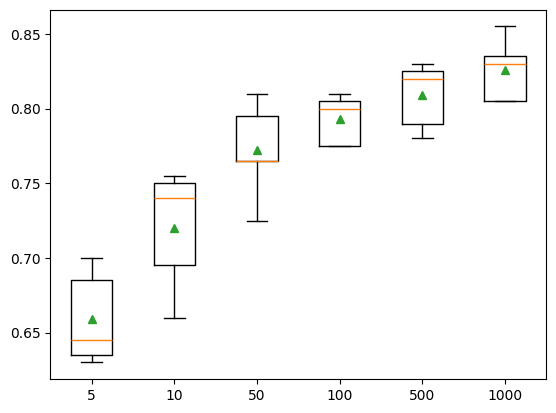

In [ ]:
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
	X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
	return X, y

# get a list of models to evaluate
def get_models():
	models = dict()
	# define number of trees to consider
	n_trees = [5, 10, 50, 100, 500, 1000]
	for n in n_trees:
		models[str(n)] = AdaBoostClassifier(n_estimators=n, learning_rate=0.1)
	return models


# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
	# define the evaluation procedure
	cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=1)
	# evaluate the model and collect the results
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
	return scores


#if not

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()

results, names = list(), list()
for name, model in models.items():
	# evaluate the model
	scores = evaluate_model(model, X, y)
	# store the results
	results.append(scores)
	names.append(name)
	# summarize the performance along the way
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

In [ ]:
results=[]
names=[]

from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
# define dataset
svc=SVC(probability=True, kernel='linear')
lr=LogisticRegression()
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
models=[svc,lr]
# define the model
for i in models:
  model = AdaBoostClassifier(base_estimator=i,n_estimators=50,learning_rate=0.1)
  # evaluate the model
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=1)
  n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
  # report performance
  results.append(n_scores)
  names.append(i)
  print('Accuracy for {} : %.3f (%.3f)' % (mean(n_scores), std(n_scores)))



Accuracy for {} : 0.800 (0.020)
Accuracy for {} : 0.800 (0.020)
